## Grain boundary segregation

This notebook calculates how strongly different solute atoms segregate to a grain boundary. Grain boundaries contain atomic sites with distorted local environments, some compressed and some expanded relative to the perfect crystal. Solutes that are a poor fit in the bulk lattice can lower the system's energy by moving to sites better matching their size. This segregation changes boundary cohesion, mobility and corrosion behaviour, so it is central to designing alloys.

The workflow first relaxes a bulk aluminium supercell and a Σ5 (120)[001] tilt grain boundary, letting both atomic positions and the cell itself relax so that the clean references are stress-free. It then identifies the symmetrically distinct sites in each by their Steinhardt bond-order parameters. Each solute is substituted into every distinct bulk and grain boundary site, and the structure is relaxed again, but this time only the atomic positions are relaxed. The segregation energy at a site is the energy of the solute there relative to its most favourable bulk site: $E_\mathrm{seg} = (E_\mathrm{GB+X} + E_\mathrm{bulk}) - (E_\mathrm{GB} + E_\mathrm{bulk+X})$, with negative values meaning segregation is favourable.

Holding the cell fixed is the standard dilute-limit approximation, which models a single solute in an effectively infinite host. In a finite periodic supercell, however, each solute interacts with its own periodic images, and the strain field it creates cannot be relieved by the cell. Both effects bias the energies by an amount that shrinks as the supercell grows; the bulk-like site in the grain boundary cell, whose segregation energy should be zero, can thus be exploited as a direct check on how large this finite-size error is.

To connect segregation to local geometry, we use Voronoi volumes. A Voronoi construction divides space into one cell per atom, containing all the points closer to that atom than to any other, so each cell's volume is a natural measure of how much room that particular site has. We compute these per-site volumes in the clean, relaxed structures; subtracting the volume of the bulk reference site gives each grain boundary site's excess volume, positive for expanded sites and negative for compressed ones. Plotting segregation energy against excess volume shows whether a solute prefers compressed or expanded sites. We scan Cu, Ag, Au and Ni with an EMT potential.

In [1]:
from collections.abc import Iterable
import itertools
import importlib.metadata
import pathlib
import shutil

import ase
import bagofholding as boh
import numpy as np
import pyiron_workflow as pwf
from matplotlib import pyplot as plt
from pyiron_workflow_atomistics import engine as engine_mod

import pmd03

In [2]:
wf = pwf.Workflow("segregation_wf")
wf.segregation = pwf.node(pmd03.volumetric_segregation)

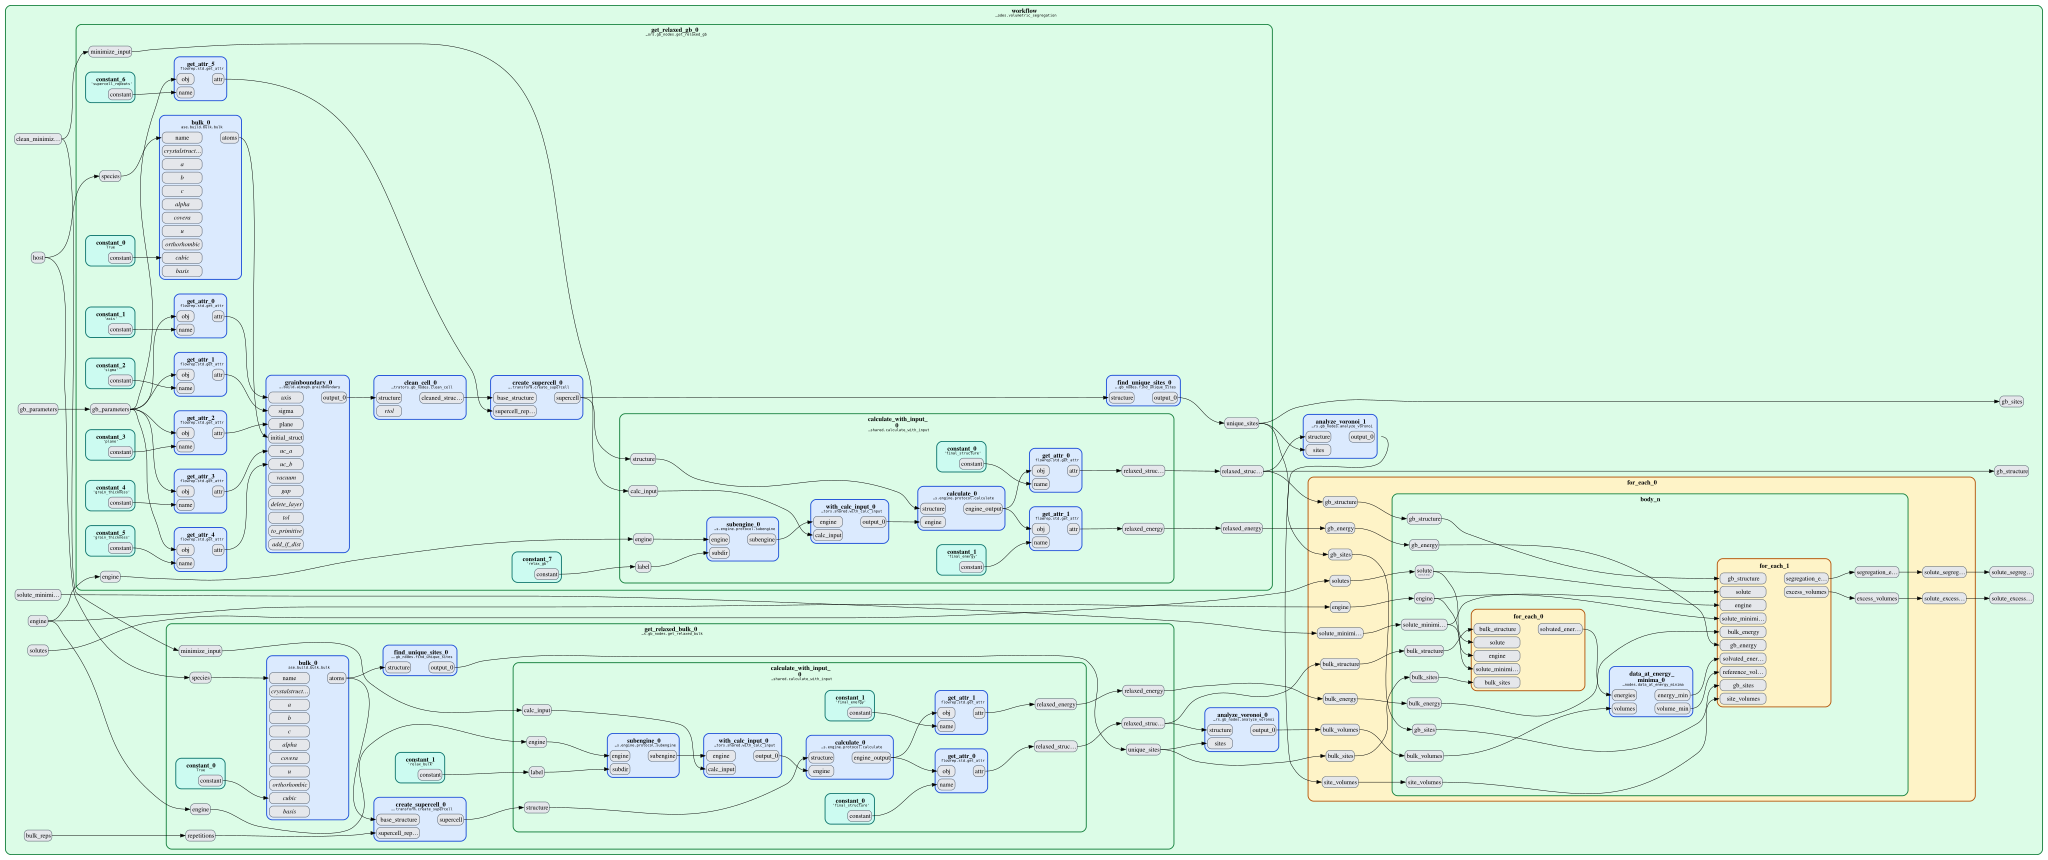

In [3]:
wf.segregation.draw(depth=2)

The python library only has the steps for actually running the calculations; Now, we'll extend this core functionality by adding a plotting node to the end our workflow

In [4]:
def _plot_energies(
    solutes: Iterable[str],
    excess_volumes: list[list[float]],
    energies: list[list[float]],
    marker_cycle: itertools.cycle,
    ax: plt.Axes | None = None,
):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    for solute, volumes, segregation in zip(solutes, excess_volumes, energies, strict=True):
        ax.scatter(volumes, segregation, label=solute, marker=next(marker_cycle))
        ax.set_xlabel("Site voronoi volume (Cubic Å)")
        ax.set_ylabel("Segrgation energy (eV)")

    return ax


def _plot_structure(
    structure: ase.Atoms,
    sites: list[int],
    site_excess_volumes: list[float],
    label_sites: bool = False,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Plot the xy projection of `structure`, highlighting `sites`.

    Args:
        structure: The structure to project onto the xy plane.
        sites: Indices of the special sites (columns) to highlight.
        site_volumes: One value per entry of `sites`, annotated to 2 d.p.
    """
    if len(sites) != len(site_excess_volumes):
        raise ValueError(
            f"len(sites)={len(sites)} != len(site_volumes)={len(site_excess_volumes)}"
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    positions = structure.get_positions()
    mask = np.zeros(len(structure), dtype=bool)
    mask[np.asarray(sites, dtype=int)] = True

    ax.scatter(
        positions[~mask, 0],
        positions[~mask, 1],
        s=60,
        c="lightgrey",
        edgecolors="dimgrey",
        linewidths=0.5,
        zorder=2,
    )
    ax.scatter(
        positions[mask, 0],
        positions[mask, 1],
        s=90,
        c="crimson",
        edgecolors="black",
        linewidths=0.7,
        zorder=3,
    )

    if label_sites:
        for index, volume in zip(sites, site_excess_volumes, strict=True):
            ax.annotate(
                # f"{volume:.2f}",
                f"{index}",
                xy=positions[index, :2],
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                zorder=4,
                color="blue",
            )

    ax.set_aspect("equal")
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")
    return ax


def plot_structure_and_energies(
    structure: ase.Atoms,
    sites: list[int],
    excess_volumes: list[list[float]],
    solutes: Iterable[str],
    energies: list[list[float]],
    panel_height: float = 6.0,
    energy_width_ratio: float = 4.5,
) -> plt.Figure:
    """Draw the structure projection and the E(V) curves side by side."""
    fig, (ax_structure, ax_energies) = plt.subplots(
        1,
        2,
        figsize=(panel_height, panel_height),  # overwritten below
        gridspec_kw={"width_ratios": [1.0, energy_width_ratio]},
        layout="constrained",
    )

    _plot_structure(structure, sites, excess_volumes[0], ax=ax_structure)
    _plot_energies(
        solutes,
        excess_volumes,
        energies,
        marker_cycle=itertools.cycle("os^vD*"),
        ax=ax_energies,
    )

    # Rendered aspect (height / width) of the structure panel, taken from the
    # data limits *after* plotting so margins are included.
    x_lo, x_hi = ax_structure.get_xlim()
    y_lo, y_hi = ax_structure.get_ylim()
    aspect = abs(y_hi - y_lo) / abs(x_hi - x_lo)

    ax_structure.set_box_aspect(aspect)
    ax_energies.set_box_aspect(aspect / energy_width_ratio)

    structure_width = panel_height / aspect
    fig.set_size_inches(structure_width * (1.0 + energy_width_ratio), panel_height)
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
    return fig

In [5]:
wf.set_inputs_to_unconnected_child_input()

wf.fig = pwf.node(
    plot_structure_and_energies,
    structure=wf.segregation.outputs.gb_structure,
    sites=wf.segregation.outputs.gb_sites,
    excess_volumes=wf.segregation.outputs.solute_excess_volumes,
    solutes=wf.inputs.segregation__solutes,
    energies=wf.segregation.outputs.solute_segregation_energies,
)

wf.create_output_from(wf.fig)

[AddOutput(port=OutputPort(label='fig', owner=<pyiron_workflow.workflow_node.Workflow object at 0x10f6817f0>, type_hint=<class 'matplotlib.figure.Figure'>, type_metadata=None)),
 AddEdge(edge=EdgeTuple(source=SourceHandle(node='fig', port='fig'), target=OutputTarget(node=None, port='fig')))]

As of version 1.4.4, `semantikon` cannot parse for-loops (or other flow controls) into knowledge graphs, so we can't look into the full knowledge graph here.

Running the full scan takes a few minutes. To accelerate the process, we provide an already-computed version for you saved in a `bagofholding.H5Bag` hdf5 file. If that's here, we'll just load it; you can move/delete this file to force a re-run.

In [6]:
# Set True for quick, low-fidelity settings -- good for testing, not for interesting physics
cheap = True

# If there's a cached result, use it
use_result = True

# If we ran, (over)write the existing cache
write_result = True

      Step     Time          Energy          fmax
BFGS:    0 11:40:31       -0.048066        5.177401
BFGS:    1 11:40:31        1.542253       19.315875
BFGS:    2 11:40:31       -0.154186        0.721891
BFGS:    3 11:40:31       -0.156157        0.149685
BFGS:    4 11:40:31       -0.156246        0.000301
      Step     Time          Energy          fmax
BFGS:    0 11:40:32       61.870834      248.591150
BFGS:    1 11:40:32       53.254512      145.186509
BFGS:    2 11:40:33       31.992509      249.720754
BFGS:    3 11:40:33      211.980620     1869.245692
BFGS:    4 11:40:33       63.206393      408.133725
BFGS:    5 11:40:33       22.009524      195.657471
BFGS:    6 11:40:34       51.408212      501.350057
BFGS:    7 11:40:34       16.075828       45.621535
BFGS:    8 11:40:34       14.406489       49.042830
BFGS:    9 11:40:34       64.330025      609.635992
BFGS:   10 11:40:35       12.647180       30.251157
BFGS:   11 11:40:35       12.290839       15.714405
BFGS:   12 11:40

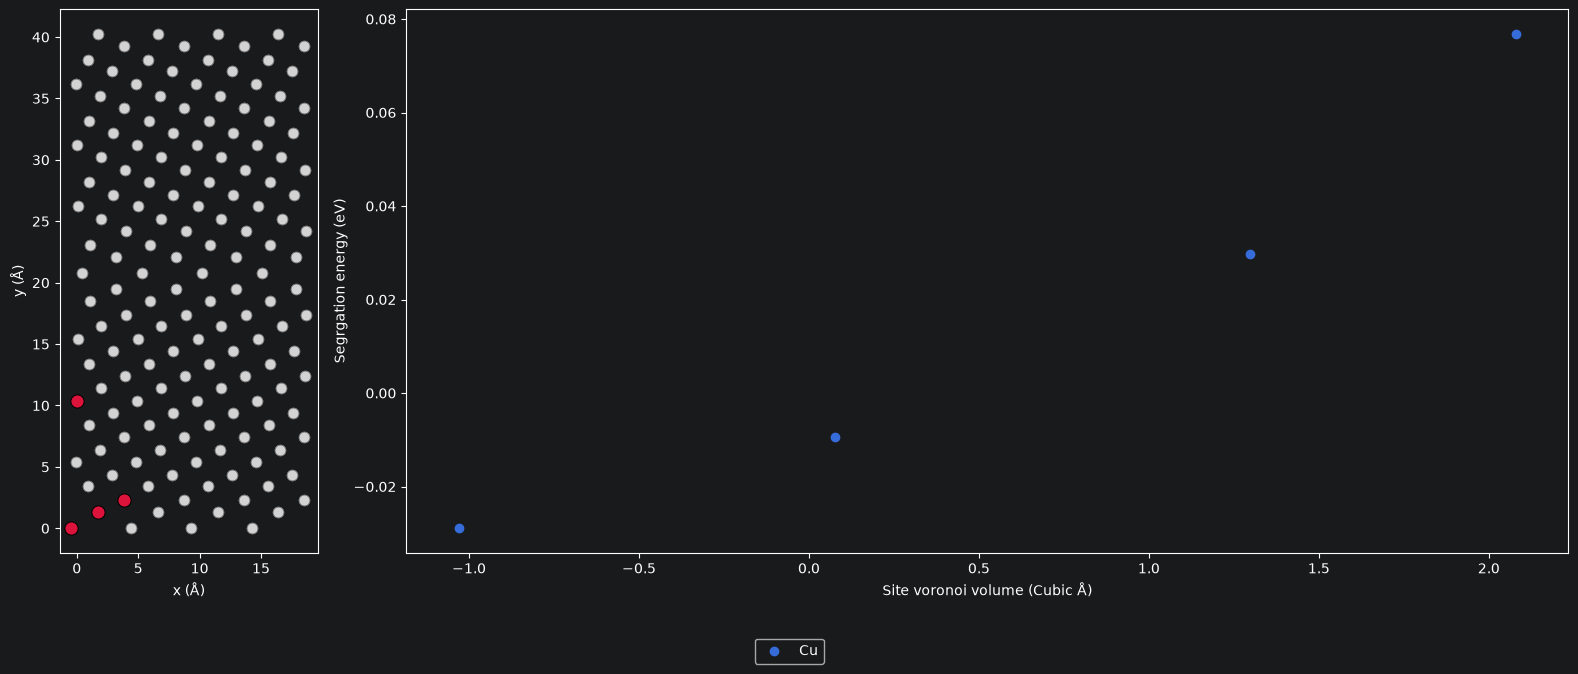

In [9]:
# pyiron_workflow_atomistics 0.2.2 reports a git-derived `__version__`; use its
# installed package version instead
version_scraping = {"pyiron_workflow_atomistics": importlib.metadata.version}
result_file = pathlib.Path("results/gb_run.h5")

if use_result:
    segregation_run = boh.H5Bag(result_file).load(version_scraping=version_scraping, version_validator="semantic-minor")
else:
    WORKING_DIR = "demo_runs"

    engine = engine_mod.ASEEngine(
        EngineInput=None,
        calculator=pmd03.SerializableEMT(),
        working_directory=WORKING_DIR,
        record_interval=100,
    )

    if cheap:
        solutes = ["Cu"]
        bulk_reps = 2
        grain_thickness = 2
    else:
        solutes = ["Cu", "Ag", "Au", "Ni"]
        bulk_reps = 3
        grain_thickness = 3

    segregation_run = wf.run(
        segregation__host="Al",
        segregation__solutes=solutes,
        segregation__bulk_reps=bulk_reps,
        segregation__gb_parameters=pmd03.GBParameters(
            axis=(0, 0, 1),
            sigma=5,
            plane=(1, 2, 0),
            grain_thickness=grain_thickness,
            supercell_repeats=(2, 1, 3),
        ),
        segregation__engine=engine.with_working_directory("grain_boundary"),
        segregation__clean_minimize_input=engine_mod.CalcInputMinimize(relax_cell=True),
        segregation__solute_minimize_input=engine_mod.CalcInputMinimize(relax_cell=False),
    )

    if write_result:
        result_file.parent.mkdir(exist_ok=True)
        boh.H5Bag.save(
            segregation_run,
            result_file,
            overwrite_existing=True,
            version_scraping=version_scraping,
        )

    shutil.rmtree(WORKING_DIR)

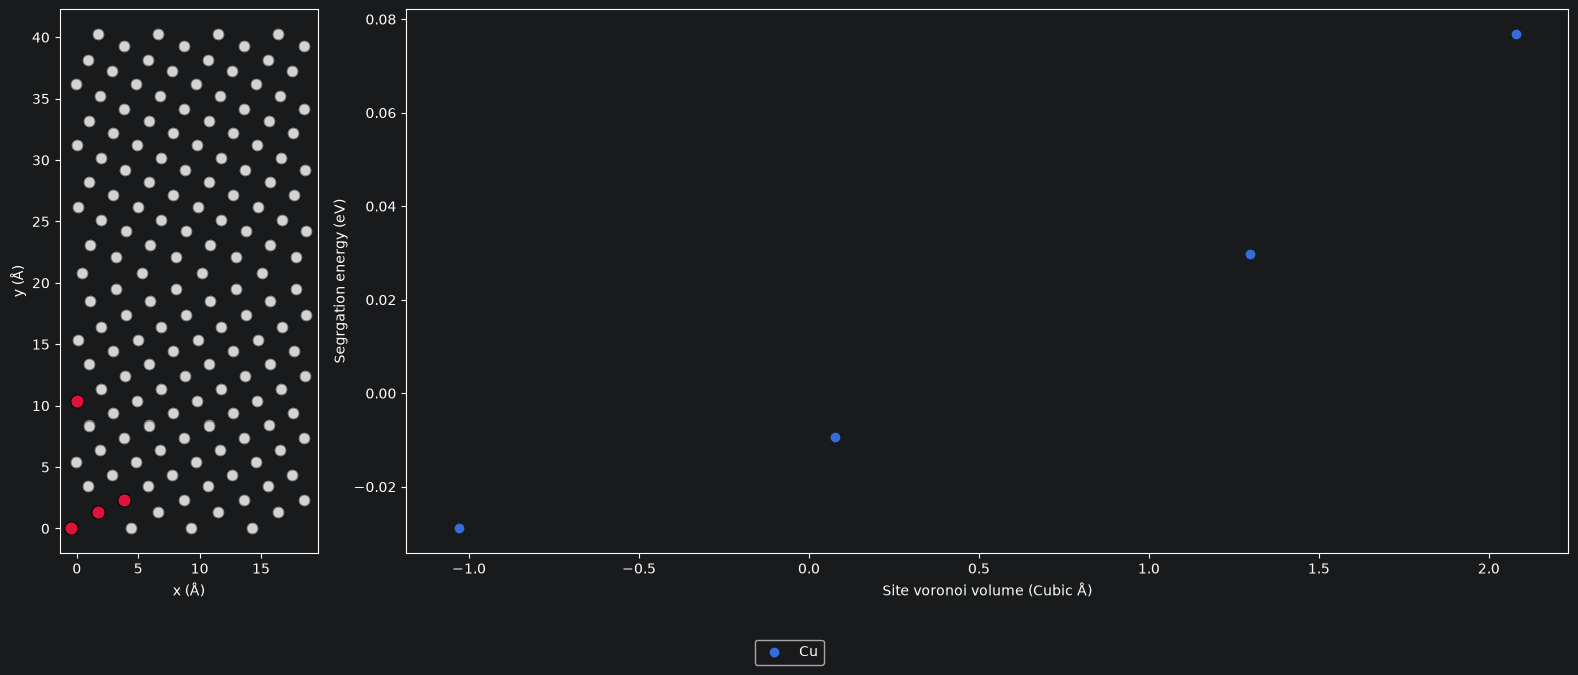

In [10]:
segregation_run.outputs.fig

We find copper and nickle preferring compressive sites, while silver and gold prefer expansive sites.

The site with near-zero excess volume is the bulk-like site; nearness of volume differential and segregation energy to zero give a proxy for how well-converged results are with respect to system size. In this case, we see that both energies and volumes at the bulk-like site are small but not trivial compared to GB sites.